# Mini Project 4

**2025 Introduction to Quantiative Methods in Finance**

**The Erdös Institute**

In the lectures we explored how to delta hedge sold call options, resulting in a trading strategy whose profits are neutral to upward or downward drift in a stock path movements, provided the volatility, or $\sigma$, of the stock remained constant.

For this final mini project explore the impact of a non-constant $\sigma$ on the distribution of profits of hedging. You are also encouraged to explore/research a $\sigma$-hedging strategy and write code that simulates the profit distribution of the $\sigma$-hedging strategy. 

Below is some code you can customize that simulates a stock path whose $\sigma$ is not constant.

You are encouraged to use a different model for sigma then the one provided. You can use stock paths simulated by Heston model? You could use a GARCH model for volatility. The choice is yours and you can do your own research to choose how to model a stock movement. 

# Mini Project 4: Delta Hedging under Stochastic Volatility
### Yichen Li

This project evaluates the performance of delta hedging for a European call option under three different volatility dynamics:

1. **Regime Switching Volatility** – Discrete model switching between low, medium, and high volatilities.
2. **Heston Model** – Stochastic volatility with mean reversion.
3. **GARCH(1,1)** – Volatility clustering with feedback from previous returns.

I simulate 2500 stock paths over 252 trading days (1 year), apply delta hedging daily using Black-Scholes delta, and analyze profit distributions.


In [4]:
#Package Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
np.random.seed(42)
sns.set_style('darkgrid')

In [5]:

def d1(S, K, sigma, tau, r=0.035):
    return (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))

def bs_call_delta(S, K, sigma, tau, r=0.035):
    return norm.cdf(d1(S, K, sigma, tau, r))


def stock_path_custom_sigma(S0, t, r, mu, n_paths, n_steps):
    '''
    Generation of custom stock paths following Geometeric Brownian motion,
    but log-returns do not have constant volatility.
    
    Each step of the log-returns, there is a 
    1) 50% the volatility is .2
    2) 30% chance the volatility is .3
    3) 20% chance the volatility is .45
    
    Inputs:
    S0 (float): initial stock value
    t (float): time interval of stock path movements in years
    r (float): risk-free interest rate
    mu (float): drift of log-returns
    n_paths (int): number of stock paths
    n_steps (float): number of steps in each stock path
    
    Returns:
    
    Simuatled stock paths
    '''
    
    #Noise in volatility
    noise = np.random.normal(0,1,size = (n_paths, n_steps))
    
    #Custom sigma that is not constant
    sigma = np.random.choice([.2,.3,.45], p = [.5, .3, .2], size = (n_paths, n_steps))
    
    #Time increment between each step
    dt = t/n_steps
    
    #log-returns between each step
    increments = (mu + r - .5*sigma**2)*dt + sigma*np.sqrt(dt)*noise
    
    #Cumulative log-returns at each step
    log_returns = np.cumsum(increments, axis = 1)
    
    
    #paths
    paths = S0*np.exp(log_returns)
    
    
    #Adjoint initial value S0 at start of each simulated path
    paths = np.insert(paths, 0, S0, axis = 1)
    
    
    return paths
    
    

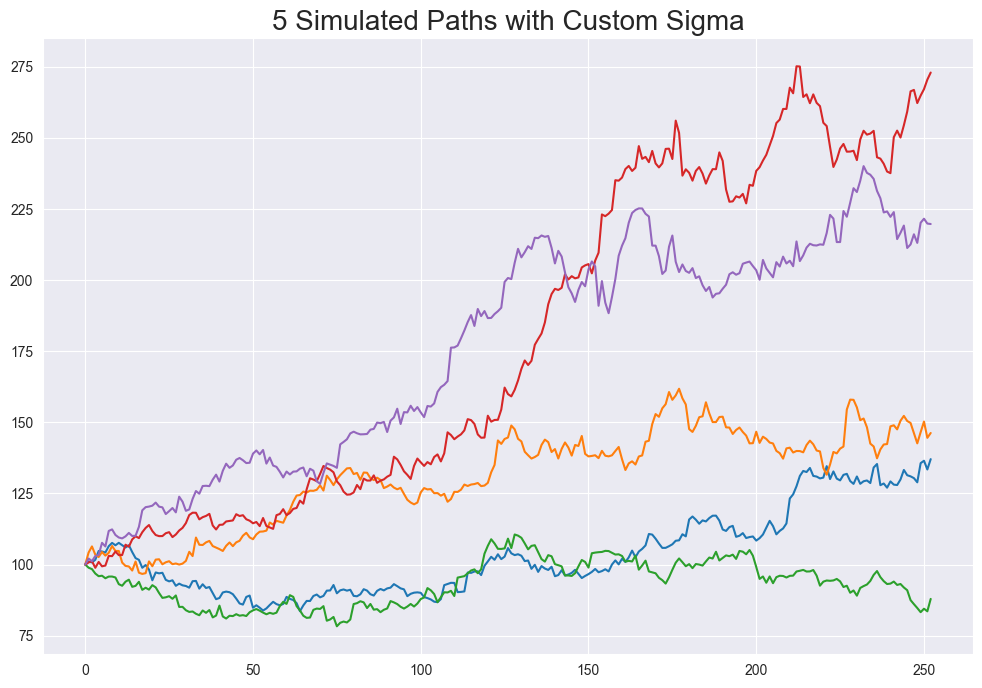

In [6]:
# Simulated paths of daily steps over 1-year period and plot

S0 = 100
t = 1
r = 0.039
mu = 0.275
n_paths = 5
n_steps = 252


simulated_paths = stock_path_custom_sigma(S0, t, r, mu, n_paths, n_steps)


plt.figure(figsize = (12,8))

for path in simulated_paths:
    plt.plot(path)
    
plt.title(f'{n_paths} Simulated Paths with Custom Sigma', size = 20)


plt.show()

In [37]:
# --- Black-Scholes Delta Function ---
def bs_call_delta(S, K, sigma, tau, r=0.035):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)

def bs_paths(S0, mu, sigma, T, N, M):
    dt = T / N
    S = np.zeros((N+1, M))
    S[0] = S0

    for t in range(1, N+1):
        z = np.random.normal(size=M)
        S[t] = S[t-1] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z)

    return S

# --- Regime-Switching Volatility Simulation ---
def simulate_regime_paths(S0, mu, regimes, probs, T, N, M, r):
    dt = T / N
    paths = np.zeros((N+1, M))
    paths[0] = S0
    
    for t in range(1, N+1):
        sigma_t = np.random.choice(regimes, size=M, p=probs)
        z = np.random.normal(size=M)
        paths[t] = paths[t-1] * np.exp((mu - 0.5 * sigma_t ** 2) * dt + sigma_t * np.sqrt(dt) * z)
    
    return paths

# --- Delta-Hedged P&L Calculation ---
def delta_hedged_pnl(paths, K, sigma, r, T):
    N, M = paths.shape[0] - 1, paths.shape[1]
    dt = T / N
    tau = T - np.arange(N) * dt
    pnl = np.zeros(M)
    
    for j in range(M):
        for i in range(N):
            Si, Si1 = paths[i, j], paths[i+1, j]
            deltai = bs_call_delta(Si, K, sigma, tau[i], r)
            pnl[j] += (Si1 - Si * np.exp(r * dt)) * deltai * np.exp(-r * (i+1) * dt)
    
    return pnl

# --- Parameter Setup ---
S0 = 100
K = 110
r = 0.035
T = 1
N = 252
M = 2500
mu = 0.0

regimes = [0.20, 0.30, 0.45]
probs = [0.5, 0.3, 0.2]


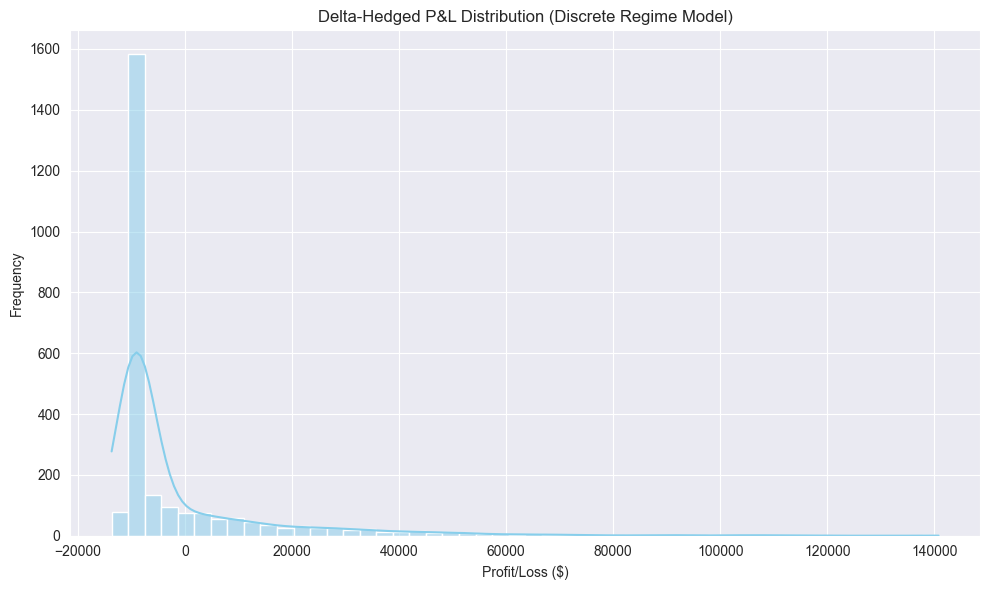

In [52]:
# --- Simulation---
paths_regime = simulate_regime_paths(S0, mu, regimes, probs, T, N, M, r)
pnl_regime = delta_hedged_pnl(paths_regime, K, 0.30, r, T) * 1000  # scaled to 1000 contracts

plt.figure(figsize=(10,6))
sns.histplot(pnl_regime, bins=50, kde=True, color='skyblue')
plt.title("Delta-Hedged P&L Distribution (Discrete Regime Model)")
plt.xlabel("Profit/Loss ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [9]:
# --- Output ---
mean_pnl = np.mean(pnl_regime)
max_loss = np.min(pnl_regime)
percent_positive = np.mean(pnl_regime > 0) * 100

print(f"Mean Profit: ${mean_pnl:.2f}")
print(f"Max Loss: ${max_loss:.2f}")
print(f"Percentage Positive: {percent_positive:.2f}%")


Mean Profit: $-1465.05
Max Loss: $-13385.47
Percentage Positive: 22.96%


In [10]:
print("""
Conclusions:
1. Delta hedging effectively neutralizes small price movements but not volatility shocks.
2. Under regime-switching volatility, P&L distribution shows fat tails and significant tail risk.
3. Even with daily hedging, large losses are possible.
""")


Conclusions:
1. Delta hedging effectively neutralizes small price movements but not volatility shocks.
2. Under regime-switching volatility, P&L distribution shows fat tails and significant tail risk.
3. Even with daily hedging, large losses are possible.



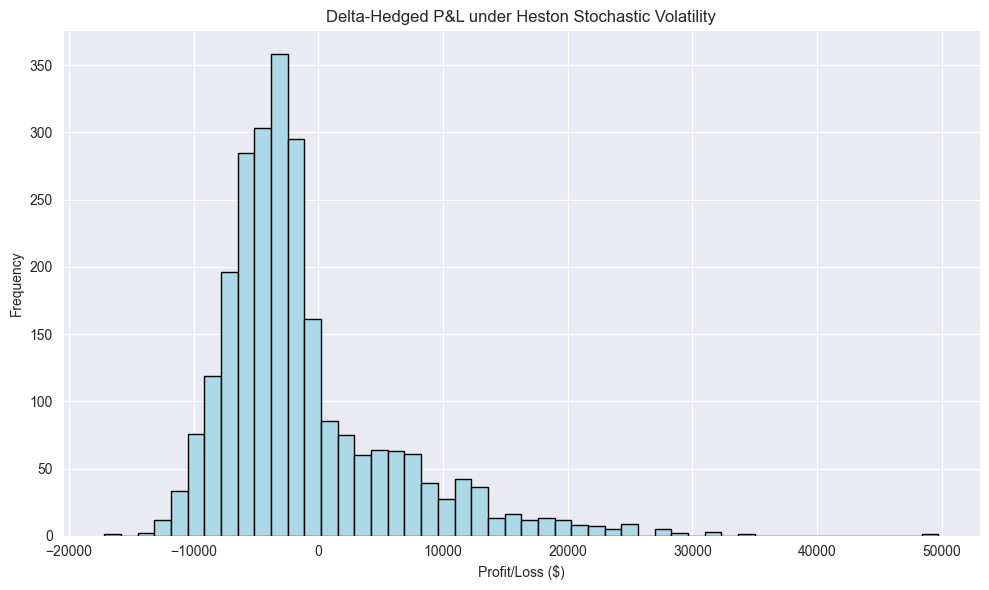

Mean Profit: $-1230.67
Max Loss: $-17176.96
Percentage Positive: 26.96%


In [18]:
#  Heston Model Simulation and Delta Hedging
# Define Heston parameters 
kappa = 2      # mean reversion speed
theta = 0.04  # long-run variance level
xi = 0.5      # volatility of volatility
rho = -0.7    # correlation between asset and volatility shocks
v0 = 0.04     # initial variance

S0 = 100
K = 110
r = 0.035
T = 1
N = 252
M = 2500
mu = 0.0



def heston_paths(S0, v0, kappa, theta, xi, rho, mu, T, N, M):
    dt = T / N
    S = np.zeros((N+1, M))
    v = np.zeros((N+1, M))
    S[0] = S0
    v[0] = v0

    for t in range(1, N+1):
        z1 = np.random.normal(size=M)
        z2 = np.random.normal(size=M)
        w1 = z1
        w2 = rho * z1 + np.sqrt(1 - rho ** 2) * z2

        v[t] = np.abs(v[t-1] + kappa*(theta - v[t-1])*dt + xi*np.sqrt(v[t-1]*dt)*w2)
        S[t] = S[t-1] * np.exp((mu - 0.5*v[t-1])*dt + np.sqrt(v[t-1]*dt)*w1)
    
    return S, v

# Delta hedging under Heston volatility
def bs_call_delta(S, K, sigma, tau, r=0.035):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)

S_heston, v_heston = heston_paths(S0, v0, kappa, theta, xi, rho, mu, T, N, M)

# Calculate daily delta-hedged P&L
pnl = np.zeros(M)
tau = T - np.arange(N) * (T/N)

for j in range(M):
    for i in range(N):
        Si, Si1 = S_heston[i, j], S_heston[i+1, j]
        sigma_i = np.sqrt(v_heston[i, j])
        delta_i = bs_call_delta(Si, K, sigma_i, tau[i], r)
        pnl[j] += (Si1 - Si * np.exp(r * (T/N))) * delta_i * np.exp(-r * (i+1) * (T/N))

pnl *= 1000  # scaled to 1000 contracts

# Plot P&L distribution
plt.figure(figsize=(10,6))
plt.hist(pnl, bins=50, color='lightblue', edgecolor='black')
plt.title('Delta-Hedged P&L under Heston Stochastic Volatility')
plt.xlabel('Profit/Loss ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Output summary statistics
print(f"Mean Profit: ${np.mean(pnl):.2f}")
print(f"Max Loss: ${np.min(pnl):.2f}")
print(f"Percentage Positive: {np.mean(pnl>0)*100:.2f}%")


### **Heston Model**
- Heston model captures **mean-reverting volatility** and volatility clustering.
- Delta-hedged P&L still shows **large tail risk**, indicating hedging does not eliminate exposure to volatility shocks.

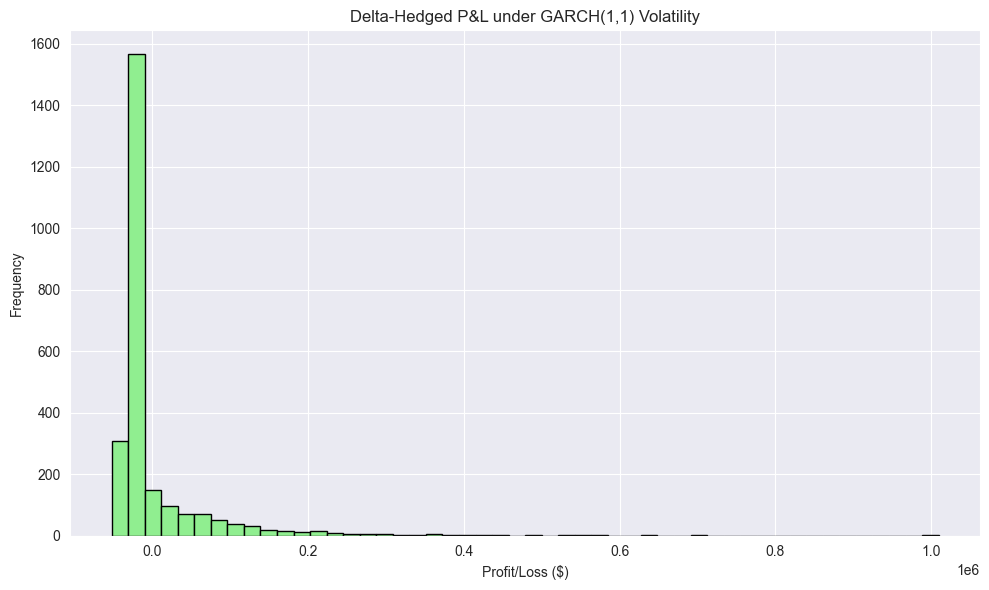

Mean Profit: $1034.21
Max Loss: $-52402.41
Percentage Positive: 22.00%


In [47]:
# Define  parameters
omega = 0.000002
alpha = 0.05
beta = 0.9

S0 = 100
K = 110
r = 0.035
T = 1
N = 252
M = 2500
mu = 0.0



def garch_paths(S0, omega, alpha, beta, mu, T, N, M):
    dt = T / N
    S = np.zeros((N+1, M))
    sigma2 = np.zeros((N+1, M))
    S[0] = S0
    sigma2[0] = omega / (1 - alpha - beta)  # unconditional variance initialization

    for t in range(1, N+1):
        z = np.random.normal(size=M)
        sigma2[t] = omega + alpha * (z**2) + beta * sigma2[t-1]
        sigma_t = np.sqrt(sigma2[t])
        S[t] = S[t-1] * np.exp((mu - 0.5 * sigma2[t]) * dt + sigma_t * np.sqrt(dt) * z)

    return S, np.sqrt(sigma2)

# Delta hedging under GARCH volatility
def bs_call_delta(S, K, sigma, tau, r=0.035):
    if np.isscalar(sigma):
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    else:
        sigma = np.asarray(sigma)
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
        d1 = d1.item()  # ensure scalar output
    return norm.cdf(d1)


S_garch, sigma_garch = garch_paths(S0, omega, alpha, beta, mu, T, N, M)

# Calculate daily delta-hedged P&L
pnl = np.zeros(M)
tau = T - np.arange(N) * (T/N)

for j in range(M):
    for i in range(N):
        Si, Si1 = S_garch[i, j], S_garch[i+1, j]
        sigma_i = sigma_garch[i, j]
        delta_i = bs_call_delta(Si, K, sigma_i, tau[i], r)
        pnl[j] += (Si1 - Si * np.exp(r * (T/N))) * delta_i * np.exp(-r * (i+1) * (T/N))

pnl *= 1000  # scaled to 1000 contracts

# Plot P&L distribution
plt.figure(figsize=(10,6))
plt.hist(pnl, bins=50, color='lightgreen', edgecolor='black')
plt.title('Delta-Hedged P&L under GARCH(1,1) Volatility')
plt.xlabel('Profit/Loss ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Output summary statistics
print(f"Mean Profit: ${np.mean(pnl):.2f}")
print(f"Max Loss: ${np.min(pnl):.2f}")
print(f"Percentage Positive: {np.mean(pnl>0)*100:.2f}%")



### **GARCH(1,1) models**
- GARCH(1,1) models volatility clustering and persistence of shocks.
- Delta hedging under GARCH volatility still shows fat tails and large potential losses, indicating hedging limitations under clustered volatility.

In [72]:

def simulate_heston_paths(S0, v0, mu, kappa, theta, xi, rho, days, n_paths):
    dt = 1/252
    S = np.zeros((days+1, n_paths))
    v = np.zeros((days+1, n_paths))
    S[0] = S0
    v[0] = v0

    for j in range(n_paths):
        for i in range(1, days+1):
            Z1 = np.random.randn()
            Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.randn()
            v_t = np.maximum(v[i-1, j], 0)
            v[i, j] = v[i-1, j] + kappa * (theta - v_t) * dt + xi * np.sqrt(v_t * dt) * Z2
            v[i, j] = np.maximum(v[i, j], 0)  # enforce non-negativity
            S[i, j] = S[i-1, j] * np.exp((mu - 0.5*v_t)*dt + np.sqrt(v_t * dt) * Z1)

    return S, np.sqrt(v)

def simulate_delta_hedging(S_paths, sigma_paths, K, r=0.035):
    dt = 1/252
    n_days, n_paths = S_paths.shape
    profits = []

    for j in range(n_paths):
        S = S_paths[:, j]
        sigma = sigma_paths[:, j]
        cash = 0
        shares = 0

        for i in range(n_days-1):
            tau = max((n_days - 1 - i) * dt, 1e-10)
            delta = bs_call_delta(S[i], K, sigma[i], tau, r)
            d_shares = delta - shares
            cash -= d_shares * S[i]
            shares = delta

        pnl = cash + shares * S[-1] - max(S[-1] - K, 0)
        profits.append(pnl * 1000)  # scaled to 1000 contracts

    return profits


C:\Users\liyic\AppData\Local\Temp\ipykernel_33376\2087360474.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))


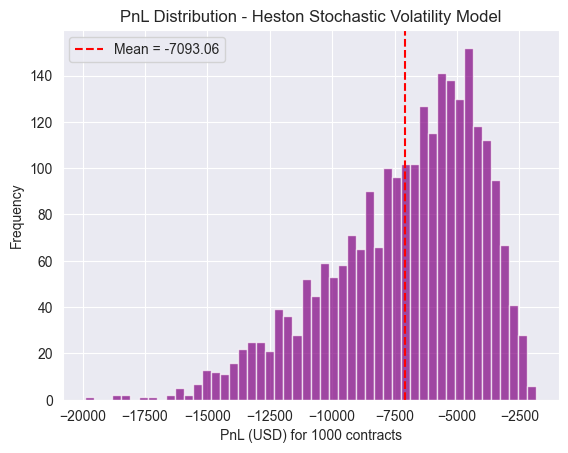

Mean: -7093.06, Std: 3025.16, Min: -19901.55, Max: -1830.82


In [74]:
# Parameters
S0 = 100
v0 = 0.04
mu = 0.05
kappa = 2.0
theta = 0.04
xi = 0.5
rho = -0.7
days = 252
n_paths = 2500
K = 100

# Simulate Heston paths
S_heston, sigma_heston = simulate_heston_paths(S0, v0, mu, kappa, theta, xi, rho, days, n_paths)
profits_heston = simulate_delta_hedging(S_heston, sigma_heston, K)

# Plot PnL distribution
plt.hist(profits_heston, bins=50, color='purple', alpha=0.7)
plt.axvline(np.mean(profits_heston), color='red', linestyle='--', label=f'Mean = {np.mean(profits_heston):.2f}')
plt.title("PnL Distribution - Heston Stochastic Volatility Model")
plt.xlabel("PnL (USD) for 1000 contracts")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean: {np.mean(profits_heston):.2f}, Std: {np.std(profits_heston):.2f}, Min: {np.min(profits_heston):.2f}, Max: {np.max(profits_heston):.2f}")